<a href="https://colab.research.google.com/github/FeLocci/senacai/blob/main/projetov2_analise_audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ---------------------------------------------------------------
# CLASSIFICAÇÃO DE ÁUDIOS - MUSICAL INSTRUMENT'S SOUND DATASET
# ---------------------------------------------------------------
# Objetivo: Classificar os sons de instrumentos (Guitarra, Bateria, Violino, Piano)
# Usando Transfer Learning com YAMNet e TensorFlow
# ---------------------------------------------------------------

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models
import tensorflow_hub as hub
import librosa
from tqdm import tqdm
import random
import kagglehub
import argparse
import shutil
import gc
import re

# ---------------------------------------------------------------
# 1. DOWNLOAD DO DATASET ---------------------------------------------------------------
path = kagglehub.dataset_download("soumendraprasad/musical-instruments-sound-dataset")
print("Path to dataset files:", path)

# ---------------------------------------------------------------
# 2. CONFIGURAÇÕES INICIAIS
# ---------------------------------------------------------------
SAMPLE_RATE = 16000
DURATION = 5  # Aumentado para 5 segundos
BATCH_SIZE = 16
NUM_CLASSES = 4
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------------
# 3. PATHS - baseado no path dinâmico do kagglehub
# ---------------------------------------------------------------
train_csv = os.path.join(path, "Metadata_Train.csv")
test_csv = os.path.join(path, "Metadata_Test.csv")
train_audio_path = os.path.join(path, "Train_submission", "Train_submission")
test_audio_path = os.path.join(path, "Test_submission", "Test_submission")

# ---------------------------------------------------------------
# 4. FUNÇÃO PARA CARREGAR ÁUDIO
# ---------------------------------------------------------------
def load_audio(file_path, duration=DURATION):
    #Load audio and skip initial silence
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    # Find first non-silent part
    non_silent = librosa.effects.trim(y, top_db=20)[0]

    # Take first DURATION seconds after silence
    if len(non_silent) > SAMPLE_RATE * duration:
        y = non_silent[:int(SAMPLE_RATE * duration)]
    else:
        y = np.pad(non_silent, (0, SAMPLE_RATE*duration - len(non_silent)), mode="constant")

    return y

# ---------------------------------------------------------------
# 5. AUGMENTATION SIMPLES
# ---------------------------------------------------------------
def augment_audio(y):
    """Aplica augmentações simples no áudio"""
    # 1) Adicionar ruído branco
    noise = np.random.randn(len(y))
    y_noise = y + 0.005 * noise

    # 2) Time shifting (deslocamento no tempo)
    shift = int(np.random.uniform(-0.1, 0.1) * SAMPLE_RATE)  # shift até 0.1s
    y_shift = np.roll(y, shift)
    if shift > 0:
        y_shift[:shift] = 0
    else:
        y_shift[shift:] = 0

    # 3) Pitch shifting (mudança de tom)
    y_pitch = librosa.effects.pitch_shift(y, sr=SAMPLE_RATE, n_steps=np.random.uniform(-2, 2))

    # Randommente escolhe uma das três augmentações
    return random.choice([y_noise, y_shift, y_pitch])

# ---------------------------------------------------------------
# 6.1 Foi identificado que os audios de violino não estão presentes na planilha de treino
# ---------------------------------------------------------------
def add_violin_samples(df, audio_folder):
    """Adiciona amostras de áudio de violino ao DataFrame."""
    new_samples = [
        {'FileName': f, 'Class': 'Sound_Violin'}
        for f in os.listdir(audio_folder)
        if 'violin' in f.lower()
    ]
    return pd.concat([df, pd.DataFrame(new_samples)], ignore_index=True)

# ---------------------------------------------------------------
# 6.2 Foi identificado erros na classificação de Violin e Drum, abaixo iremos corrigir classificação.
# ---------------------------------------------------------------
def correct_class_names(df, audio_folder, is_train=True):
    # Lista de arquivos a serem removidos de Violino porque estão inviesados
    arquivos_audio = ["04-47367.wav", "059960_sonido2-sincopa-alta-7mp3-47316.wav", "066166_qui-c39est-qu39est-tombe-loop-t85wav-39366.wav", "102-bpm-boom-groove-82498.wav", "120bpm_kick-build-up-98848.wav", "140-bpm-amen-break-original-processed-6945 (1).wav", "140-bpm-amen-break-original-processed-6945.wav", "170-beat-box-hpf-loop-103412.wav", "174-txls4-106297.wav", "2018-11-15-22563.wav", "808-boom-in-c-46330.wav", "808-d3-38858.wav", "8bit-sample-69080.wav", "african-98600.wav", "alien-beeper-103420.wav", "asian-gong-102397.wav", "atari-st-beat-09-106443.wav", "ba-dum-bum-all-74740.wav", "battle-preparations-6726.wav", "beat-of-time-128705.wav", "beatboxlong-72000.wav", "big-cinematic-impact-94799.wav", "boje-3-87816.wav", "boss-rhythm-1-37451.wav", "break-delay-88443.wav", "brushes-loop-77bpm-by-canis-et-circensis-91191.wav", "cinematic-handpan-100bpm-25170.wav", "cool-hiphop-beat-43890.wav", "crazy-rhythm-loop-120-bpm-0015-68064.wav", "crazy-rhythm-loop-120-bpm-002-68061.wav", "crazy-rhythm-loop-120-bpm-006-68062.wav", "dance-vol-1-7082.wav", "darkbeat76bpm-87710.wav", "deep-trap-beat-66414.wav", "digital-pulse-140-2-122269.wav", "dirty-rising-tube-32714.wav", "distorted-kick-1-98539.wav", "dnb-bass2-106724.wav", "dnb-bassline-170-bpm-85155.wav", "dr-tribal-percussion-triplet-loop-high-passed-106bpm-25935.wav", "dramatic-reveal-21469.wav", "dr_ni_india_01-klang-raum-wort-29461.wav", "dumdum-105423.wav", "epic-extreme-hit-109132.wav", "epic-logo-6906.wav", "epic_battle_music_1-6275.wav", "fillin-fill-timbal-edm-reggae-loop-18-12766.wav", "flying-over-the-hill-handpan-atmos-19989.wav", "freedom-in-sight-130bpm-32759.wav", "funk-bitxl-op-i1-34289.wav", "funny-light-optimistic-111775.wav", "gabber-breakbeat-145bpm-wav-103637.wav", "giant-kit-77973.wav", "glitch-beat-001-128-bpm-99953.wav", "grave-metronomico-99387.wav", "happy-day-in-beach-hand-panwav-14755.wav", "happy-loop-6978.wav", "hard-rock-logo-108960.wav", "heartbeat-fast-slowdown-31706.wav", "heartbeat-foley-34902.wav", "heavy-tribal-beat-76580.wav", "hi-hat-rhythm-89806.wav", "hihat-loop-bpm140-107127.wav", "hipsnare-85814.wav", "hitting-ride-bell-with-a-finger-98356.wav", "intro_ezezez-74457.wav", "jungleloop-87697.wav", "kc-mus152-jungle-beat-63962.wav", "kokaji-beatbox-32048.wav", "lets-dance-126506.wav", "loop-12-107632.wav", "loop-16247.wav", "loopx2-90402.wav", "mattc-hectik-beat-box-01qw-99855.wav", "menu-music-28480.wav", "metronomico-45663.wav", "minimal-beat-81778.wav", "muvibeat8_130bpm-14338.wav", "muvibeat9_130bpm-14339.wav", "new-9-42628.wav", "orch-006-cymbal-rollwav-14781.wav"]

    # Corrige Drum
    df.loc[df['FileName'].str.contains('drum', case=False, na=False), 'Class'] = 'Sound_Drum'

    # Remove linhas com Sound_Guiatr classe teste
    if not is_train:
        df.loc[df['Class'] == 'Sound_Guiatr', 'Class'] = 'Sound_Guitar'

    # Remove os arquivos da lista
    df = df[~df['FileName'].isin(arquivos_audio)]

    # Adiciona amostras de violino se for conjunto de treino
    if is_train:
        df = add_violin_samples(df, audio_folder)

    return df

# ---------------------------------------------------------------
# 6.3 ANÁLISE DE ESPECTROGRAMAS PARA IDENTIFICAÇÃO DE OUTLIERS
# ---------------------------------------------------------------
def plot_melspectrogram(audio_path, sr=SAMPLE_RATE):
    """
    Plota o espectrograma mel de um arquivo de áudio
    """
    y = load_audio(audio_path)
    mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mel_spect_db,
                           sr=sr,
                           x_axis='time',
                           y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel Spectrogram - {os.path.basename(audio_path)}')
    plt.show()

def plot_class_spectrograms(df, audio_folder, class_name, n_samples=1):
    """
    Plota espectrogramas mel de n_samples aleatórios de uma classe
    """
    class_files = df[df['Class'] == class_name]['FileName'].sample(n_samples)

    for file in class_files:
        audio_path = os.path.join(audio_folder, file)
        try:
            if os.path.exists(audio_path):
                plot_melspectrogram(audio_path)
                plt.tight_layout()
            else:
                print(f"Warning: File not found: {audio_path}")
        except Exception as e:
            print(f"Error processing file {file}: {str(e)}")
            continue

# ---------------------------------------------------------------
# 6.4 REPRODUZIR AMOSTRAS DE ÁUDIO PARA VERIFICAÇÃO AUDITIVA
# ---------------------------------------------------------------
def play_samples(df, audio_folder, sample='Sound_Violin'):
    """
    Reproduz os primeiros 3 segundos de cada amostra
    """
    import sounddevice as sd
    import time

    # Filtrar apenas amostras
    samples = df[df['Class'] == sample]

    print(f"\nEncontradas {len(samples)} amostras de {sample}.")
    print("Reproduzindo amostras sequencialmente. Pressione Ctrl+C para parar.")

    for _, row in samples.iterrows():
        try:
            file_path = os.path.join(audio_folder, row['FileName'])
            if os.path.exists(file_path):
                # Carregar apenas 3 segundos
                audio = load_audio(file_path, duration=3)

                # Mostrar arquivo atual
                print(f"\nReproduzindo: {row['FileName']}")

                # Reproduzir áudio
                sd.play(audio, SAMPLE_RATE)
                sd.wait()  # Esperar até o áudio terminar

                # Pequena pausa entre amostras
                time.sleep(1)
            else:
                print(f"Arquivo não encontrado: {file_path}")

        except KeyboardInterrupt:
            print("\nReprodução interrompida pelo usuário")
            sd.stop()
            break
        except Exception as e:
            print(f"Erro ao reproduzir {row['FileName']}: {str(e)}")
            continue

# ---------------------------------------------------------------
# 6.5 PREPARAR DATASET COM AUGMENTATION E BALANCEAMENTO
# ---------------------------------------------------------------
def prepare_dataset(csv_file, audio_folder, augment=True, balance=True, instrument_map=None, is_train=True):
    df = pd.read_csv(csv_file)

    # Corrigir nomes de classes e remover entradas inválidas
    df = correct_class_names(df, audio_folder, is_train)

    # Se um instrument_map for fornecido, usa ele (útil para garantir mesmas classes entre treino/test)
    if instrument_map is None:
        instrument_map = {}
        for idx, class_name in enumerate(sorted(df['Class'].unique())):
            instrument_map[class_name] = idx
        print("Mapeamento de classes (criado):", instrument_map)
    else:
        # Filtra qualquer linha cuja classe não exista no mapping fornecido
        print("Usando instrument_map fornecido:", instrument_map)
        df = df[df['Class'].isin(instrument_map.keys())]

    # Carregar arquivos por classe
    data = {cls: [] for cls in instrument_map.keys()}
    missing_files = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Processando áudios"):
        file_name = row['FileName']
        class_name = row['Class']
        file_path = os.path.join(audio_folder, file_name)
        if not os.path.exists(file_path):
            missing_files += 1
            print(f"Aviso: arquivo não encontrado {file_path}")
            continue
        audio = load_audio(file_path)
        # Se a classe não está no mapping (quando foi filtrado acima isso não acontece), pula
        if class_name not in data:
            continue
        data[class_name].append(audio)

    print(f"Arquivos faltantes: {missing_files}")

    # Balancear e aplicar augmentation
    if balance:
        # ignora classes sem amostras ao calcular max_count
        counts = [len(audios) for audios in data.values() if len(audios) > 0]
        max_count = max(counts) if counts else 0
    else:
        max_count = None  # Sem balanceamento

    X, y = [], []
    for class_name, audios in data.items():
        if len(audios) == 0:
            print(f"Aviso: nenhuma amostra encontrada para classe {class_name}, será ignorada.")
            continue
        audios_copy = audios.copy()
        # Se balancear, repetir e augmentar para atingir max_count
        if balance and max_count > 0:
            while len(audios_copy) < max_count:
                audio_to_augment = random.choice(audios)
                augmented_audio = augment_audio(audio_to_augment) if augment else audio_to_augment
                audios_copy.append(augmented_audio)
        # Agora adiciona os áudios (originais + augmentados)
        for audio in audios_copy:
            X.append(audio)
            y.append(instrument_map[class_name])

    return np.array(X), np.array(y), instrument_map

# ---------------------------------------------------------------
# 7. CARREGAR DATASETS
# ---------------------------------------------------------------
print("Preparando dataset de treino com augmentation e balanceamento...")
X_train, y_train, instrument_map = prepare_dataset(train_csv, train_audio_path, augment=True, balance=True, is_train=True)

print("Preparando dataset de teste (sem augmentation)...")
# reutiliza instrument_map do treino para manter indices consistentes
X_test, y_test, _ = prepare_dataset(test_csv, test_audio_path, augment=False, balance=False, instrument_map=instrument_map, is_train=False)

# Divisão treino/validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# ---------------------------------------------------------------
# 8. TRANSFER LEARNING COM YAMNet
# ---------------------------------------------------------------
yamnet_model_handle = "https://tfhub.dev/google/yamnet/1"
yamnet_model = hub.load(yamnet_model_handle)

def extract_embedding(audio):
    tensor_audio = tf.convert_to_tensor(audio, dtype=tf.float32)
    scores, embeddings, spectrogram = yamnet_model(tensor_audio)
    return tf.reduce_mean(embeddings, axis=0)

def preprocess_dataset(audio_list):
    embeddings = []
    for audio in tqdm(audio_list, desc="Extraindo embeddings"):
        emb = extract_embedding(audio)
        embeddings.append(emb.numpy())
    return np.array(embeddings)

print("Extraindo embeddings do treino...")
X_train_emb = preprocess_dataset(X_train)
print("Extraindo embeddings da validação...")
X_val_emb = preprocess_dataset(X_val)
print("Extraindo embeddings do teste...")
X_test_emb = preprocess_dataset(X_test)

# ---------------------------------------------------------------
# 9. NORMALIZAÇÃO DAS EMBEDDINGS
# ---------------------------------------------------------------
scaler = StandardScaler()
X_train_emb = scaler.fit_transform(X_train_emb)
X_val_emb = scaler.transform(X_val_emb)
X_test_emb = scaler.transform(X_test_emb)



Using Colab cache for faster access to the 'musical-instruments-sound-dataset' dataset.
Path to dataset files: /kaggle/input/musical-instruments-sound-dataset
Preparando dataset de treino com augmentation e balanceamento...
Mapeamento de classes (criado): {'Sound_Drum': 0, 'Sound_Guitar': 1, 'Sound_Piano': 2, 'Sound_Violin': 3}


Processando áudios: 100%|██████████| 2853/2853 [02:01<00:00, 23.54it/s]


Arquivos faltantes: 0
Preparando dataset de teste (sem augmentation)...
Usando instrument_map fornecido: {'Sound_Drum': 0, 'Sound_Guitar': 1, 'Sound_Piano': 2, 'Sound_Violin': 3}


Processando áudios: 100%|██████████| 80/80 [00:04<00:00, 16.59it/s]


Arquivos faltantes: 0
Extraindo embeddings do treino...


Extraindo embeddings: 100%|██████████| 3961/3961 [03:40<00:00, 17.98it/s]


Extraindo embeddings da validação...


Extraindo embeddings: 100%|██████████| 991/991 [00:51<00:00, 19.08it/s]


Extraindo embeddings do teste...


Extraindo embeddings: 100%|██████████| 80/80 [00:04<00:00, 16.08it/s]


In [2]:
# ---------------------------------------------------------------
# 10. CRIAÇÃO DO MODELO
# ---------------------------------------------------------------
model = models.Sequential([
    layers.Input(shape=(1024,)),  # YAMNet embedding size
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------------------------------------------
# 11. TREINAMENTO
# ---------------------------------------------------------------
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 30

# Definir Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitorar a perda de validação
    patience=5,         # Número de épocas sem melhora para parar o treinamento
    restore_best_weights=True # Restaura os pesos do modelo da época com a melhor val_loss
)

history = model.fit(
    X_train_emb, y_train,
    validation_data=(X_val_emb, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping] # Adicionar o callback de Early Stopping
)

model.summary()

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9119 - loss: 0.4477 - val_accuracy: 0.9808 - val_loss: 0.1045
Epoch 2/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9525 - loss: 0.2274 - val_accuracy: 0.9606 - val_loss: 0.1265
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9662 - loss: 0.1459 - val_accuracy: 0.9808 - val_loss: 0.0990
Epoch 4/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9742 - loss: 0.1028 - val_accuracy: 0.9849 - val_loss: 0.0762
Epoch 5/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9695 - loss: 0.1402 - val_accuracy: 0.9808 - val_loss: 0.0832
Epoch 6/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9748 - loss: 0.0960 - val_accuracy: 0.9859 - val_loss: 0.0945
Epoch 7/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9760 - loss: 0.0974 - val_accuracy: 0.9849 - val_loss: 0.0911
Epoch 8/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9790 - loss: 0.0740 - val_acc

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,772,942 (6.76 MB)

 Trainable params: 590,980 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,181,962 (4.51 MB)

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


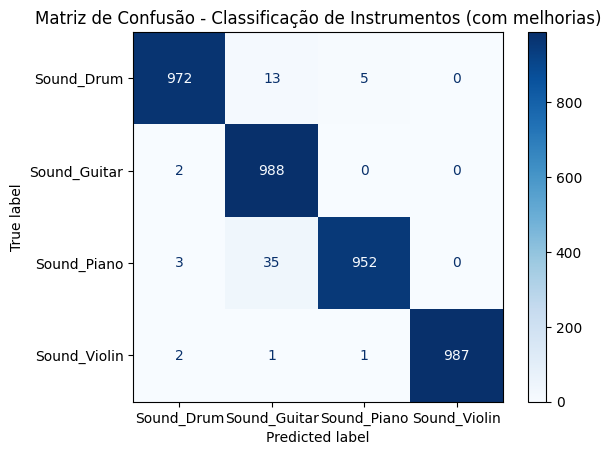

In [3]:
# ---------------------------------------------------------------
# 13. MATRIZ DE CONFUSÃO
# ---------------------------------------------------------------
y_pred = np.argmax(model.predict(X_train_emb), axis=1)
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_train, y_pred),
                              display_labels=list(instrument_map.keys()))
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Classificação de Instrumentos (com melhorias)")
plt.show()

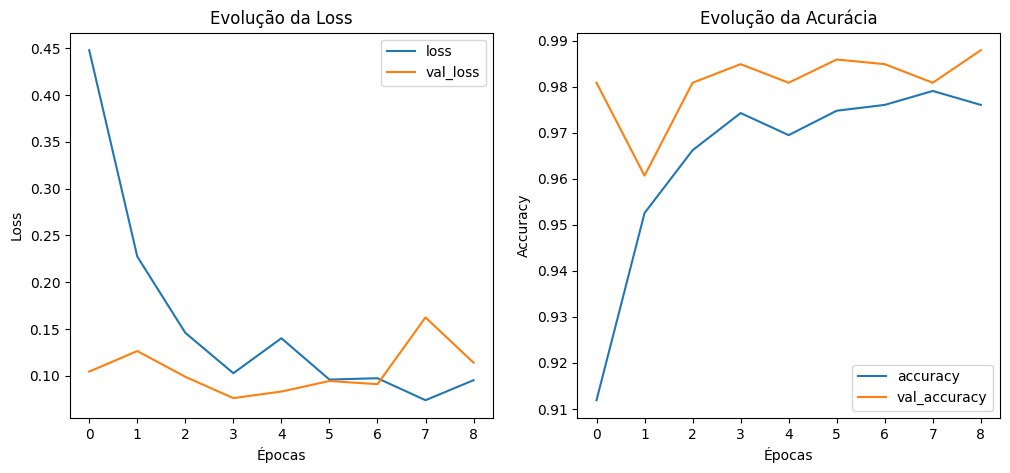

In [4]:
# ---------------------------------------------------------------
# 12. GRÁFICOS DE LOSS E ACCURACY
# ---------------------------------------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Evolução da Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Evolução da Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [8]:
import pandas as pd

print('\n--- Classificação de Amostras Aleatórias de Treino ---')

# Selecionar 10 índices aleatórios do conjunto de treino
random_indices = random.sample(range(len(X_train)), 10)

# Inverter o instrument_map para mapear de índice para nome da classe
inverse_instrument_map = {v: k for k, v in instrument_map.items()}

results = []

for i, idx in enumerate(random_indices):
    audio_sample = X_train[idx]
    true_label = y_train[idx]

    # Extrair embedding e normalizar
    sample_embedding = extract_embedding(audio_sample).numpy()
    sample_embedding_scaled = scaler.transform(sample_embedding.reshape(1, -1))

    # Fazer a previsão
    prediction_probabilities = model.predict(sample_embedding_scaled, verbose=0)[0]
    predicted_label = np.argmax(prediction_probabilities)

    # Obter os nomes das classes
    true_class_name = inverse_instrument_map[true_label]
    predicted_class_name = inverse_instrument_map[predicted_label]

    results.append({
        'Amostra': i + 1,
        'Classe Real': true_class_name,
        'Classe Prevista': predicted_class_name,
        'Correto': true_label == predicted_label
    })

df_results = pd.DataFrame(results)
display(df_results)


--- Classificação de Amostras Aleatórias de Treino ---


,Amostra,Classe Real,Classe Prevista,Correto
0,1,Sound_Guitar,Sound_Guitar,True
1,2,Sound_Drum,Sound_Drum,True
2,3,Sound_Piano,Sound_Piano,True
3,4,Sound_Guitar,Sound_Guitar,True
4,5,Sound_Guitar,Sound_Guitar,True
5,6,Sound_Drum,Sound_Drum,True
6,7,Sound_Guitar,Sound_Guitar,True
7,8,Sound_Drum,Sound_Drum,True
8,9,Sound_Guitar,Sound_Guitar,True
9,10,Sound_Violin,Sound_Violin,True
